#### The previous project demonstrated the limits of a bigram language model, and motivated the use of ML for language modeling
#### the following MLP is designed after the word-level model demonstrated by [Bengio et al. 2023](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf)
#### this project will implement the model at character-level for continuity with the previous project

In [395]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [396]:
names = open('names.txt', 'r').read().splitlines()
print(f"total names in dataset: {len(names)}")
names[:10]

total names in dataset: 32033


['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [397]:
# building a mapping between characters and integers
chars = sorted(list(set(''.join(names))))
ctoi = {c:i+1 for i,c in enumerate(chars)}
ctoi['.'] = 0
itoc = {i:c for c,i in ctoi.items()}
itoc

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

#### To construct the training dataset, a context window of 3 is established, and names are iteratively parsed to extract paired 3-gram contexts to corresponding target characters
#### e.g., the name "Emma" has 5 training examples embedded within it

In [398]:
block_size = 3
X, Y = [], []

for n in names[:3]:
    print(n)
    context = [0] * block_size
    for ch in n + '.':
        ix = ctoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itoc[i] for i in context), '--->', itoc[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .


#### the Bengio et al. paper mapped their 17,000 word vocabulary to a 30-dimensional feature space
#### lets map our 27 characters into 2D feature vectors

In [399]:
C = torch.randn((27,2))
C

tensor([[-1.7353, -1.0188],
        [ 0.2475,  1.1202],
        [ 1.6731,  1.5889],
        [ 1.0927,  0.3602],
        [-0.4889, -0.1219],
        [ 0.0183, -0.0721],
        [-0.4194, -0.3576],
        [ 1.3167,  0.7848],
        [ 0.6463,  1.9148],
        [ 1.0255,  0.9801],
        [ 1.9265,  0.2035],
        [-1.0890,  0.8802],
        [-0.4503, -1.7347],
        [-0.1420, -1.0955],
        [ 0.4124,  1.0177],
        [-0.4430,  0.9269],
        [ 0.5414,  1.4945],
        [ 0.2035, -1.6873],
        [ 1.2534,  0.5706],
        [ 0.5476, -1.1343],
        [ 0.1544,  0.7123],
        [ 0.0765,  0.0873],
        [ 1.1963, -0.9232],
        [ 0.5745,  0.4845],
        [-0.1711,  0.1141],
        [-0.3934,  0.9412],
        [-0.8622, -2.1016]])

#### retrieving the $i^{th}$ feature vector is then a matter of indexing into the embedding table $C[i]$
#### this is equivalent to (but computationally cheaper than) the one-hot encoding $X_{enc}$ approach from last project, namely $X_{enc} \cdot C = C[i]$
#### given the power of indexing tensors in pytorch, the embedding $E$ is conveniently provided by $C[X]$

In [400]:
emb = C[X]
print(f"X is the input training tensor:\n{X.shape}\n{X[:3]}\n")
print(f"C is the embedding table:\n{C.shape}\n{C[:3]}\n")
print(f"C[X] gives the embeddings for each input in the training set:\n{emb.shape}\n{emb[:3]}")

X is the input training tensor:
torch.Size([16, 3])
tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13]])

C is the embedding table:
torch.Size([27, 2])
tensor([[-1.7353, -1.0188],
        [ 0.2475,  1.1202],
        [ 1.6731,  1.5889]])

C[X] gives the embeddings for each input in the training set:
torch.Size([16, 3, 2])
tensor([[[-1.7353, -1.0188],
         [-1.7353, -1.0188],
         [-1.7353, -1.0188]],

        [[-1.7353, -1.0188],
         [-1.7353, -1.0188],
         [ 0.0183, -0.0721]],

        [[-1.7353, -1.0188],
         [ 0.0183, -0.0721],
         [-0.1420, -1.0955]]])


In [401]:
num_neurons = 100
w1 = torch.randn(6, num_neurons)
b1 = torch.randn(num_neurons)

#### as it stands, $E_{i\times{j}\times{k}}$ where $i, j, k$ are the number of training inputs, context length, and feature space dimensionality respectively
#### to compute the activations $h_1 = E \cdot w_1 + b_1$, $j$ and $k$ must be collapsed
#### pytorch has several tensor methods to handle this operation


In [402]:
# inefficient and context-dependent way to do it
torch.cat((emb[:,0,:], emb[:,1,:], emb[:,2,:]), 1).shape

torch.Size([16, 6])

In [403]:
# inefficient and context-agnostic way to do it
torch.cat(torch.unbind(emb,1), 1).shape

torch.Size([16, 6])

In [404]:
# production-standard way to do it with torch.view()
a = torch.arange(8)
print(f"given A:\n{a}\n")
print(f"A.view(2, 4):\n{a.view(2,4)}\n")
print(f"A.view(2,2,2):\n{a.view(2,2,2)}\n")
print(f"the contents of A in memory are always stored as a 1D vector of numbers:\n{a.storage()}\n")
print(f"and the same method can be used to achieve the collapse of emb:\n{emb.view(16,6)}")

given A:
tensor([0, 1, 2, 3, 4, 5, 6, 7])

A.view(2, 4):
tensor([[0, 1, 2, 3],
        [4, 5, 6, 7]])

A.view(2,2,2):
tensor([[[0, 1],
         [2, 3]],

        [[4, 5],
         [6, 7]]])

the contents of A in memory are always stored as a 1D vector of numbers:
 0
 1
 2
 3
 4
 5
 6
 7
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 8]

and the same method can be used to achieve the collapse of emb:
tensor([[-1.7353, -1.0188, -1.7353, -1.0188, -1.7353, -1.0188],
        [-1.7353, -1.0188, -1.7353, -1.0188,  0.0183, -0.0721],
        [-1.7353, -1.0188,  0.0183, -0.0721, -0.1420, -1.0955],
        [ 0.0183, -0.0721, -0.1420, -1.0955, -0.1420, -1.0955],
        [-0.1420, -1.0955, -0.1420, -1.0955,  0.2475,  1.1202],
        [-1.7353, -1.0188, -1.7353, -1.0188, -1.7353, -1.0188],
        [-1.7353, -1.0188, -1.7353, -1.0188, -0.4430,  0.9269],
        [-1.7353, -1.0188, -0.4430,  0.9269, -0.4503, -1.7347],
        [-0.4430,  0.9269, -0.4503, -1.7347,  1.0255,  0.9801],
 

#### the hidden layer activations are softmaxed to produce logits (as in the previous project)

In [405]:
h = torch.tanh(emb.view(-1,6) @ w1 + b1)

# now the logits are computed
w2 = torch.randn((num_neurons, 27))
b2 = torch.randn(27)
logits = h @ w2 + b2 # [16, 27]

#### the manual computation of the loss $= mean(-\log(L))$ from before is implemented in pytorch as **cross_entropy()**
#### besides the memory and computation speed advantage in the forward and backward pass, it protects from overflow during optimization by subtracting the max logit before exponentiation (danger with large positive logits)

In [406]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)
loss = -prob[torch.arange(16), Y].log().mean()
print(loss)
print(F.cross_entropy(logits, Y))

tensor(22.4668)
tensor(22.4668)


#### strung all together, the 3-gram model is implemented as:

In [242]:
# constructing the training set
block_size = 3
X, Y = [], []

for n in names:
    context = [0] * block_size
    for ch in n + '.':
        ix = ctoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)
print(f"number of training examples = {len(X)}")

number of training examples = 228146


In [408]:
# model paramaters
C = torch.randn((27,2))
num_neurons = 100
w1 = torch.randn(6, num_neurons)
b1 = torch.randn(num_neurons)
w2 = torch.randn((num_neurons, 27))
b2 = torch.randn(27)
parameters = [C, w1, b1, w2, b2]

for p in parameters:
    p.requires_grad = True
    
print(f"number of parameters = {sum(p.nelement() for p in parameters)}")

number of parameters = 3481


In [235]:
# optimization (RL)
batch_size = 64
learning_rate = 0.1

for k in range(201):
    # batch the training data to optimize
    ix = torch.randint(0, X.shape[0], (batch_size,))
    
    # forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1,6) @ w1 + b1)
    logits = h @ w2 + b2 # [16, 27]
    loss = F.cross_entropy(logits, Y[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update parameters
    for p in parameters:
        p.data -= learning_rate * p.grad
    if k % 25 == 0:
        print(f"epoch {k} | loss = {loss}")

epoch 0 | loss = 16.311365127563477
epoch 25 | loss = 6.512736797332764
epoch 50 | loss = 4.434731483459473
epoch 75 | loss = 4.101220607757568
epoch 100 | loss = 3.6140668392181396
epoch 125 | loss = 3.470285415649414
epoch 150 | loss = 3.1642870903015137
epoch 175 | loss = 2.7982606887817383
epoch 200 | loss = 3.016957998275757


#### finding the optimal learning rate

In [225]:
# initializing an exponentially increasing collection of learning rates between 0.001 and 1
lre = torch.linspace(-3, 0, 1000) # exponents
lrs = 10**lrs # learning rates

In [248]:
# optimization (RL)
batch_size = 64

lr_i = []
loss_i = []

for i in range(1000):
    # batch the training data to optimize
    ix = torch.randint(0, X.shape[0], (batch_size,))
    
    # forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1,6) @ w1 + b1)
    logits = h @ w2 + b2 # [16, 27]
    loss = F.cross_entropy(logits, Y[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update parameters
    lr = lrs[i]
    for p in parameters:
        p.data -= lr * p.grad
    if i % 250 == 0 or i == 999:
        print(f"epoch {i} | loss = {loss}")

    lr_i.append(lre[i])
    loss_i.append(loss.item())

epoch 0 | loss = 13.01174259185791
epoch 250 | loss = 8.674545288085938
epoch 500 | loss = 3.654458522796631
epoch 750 | loss = 3.1753718852996826
epoch 999 | loss = 9.371953964233398


min loss occurs at lr=0.093966


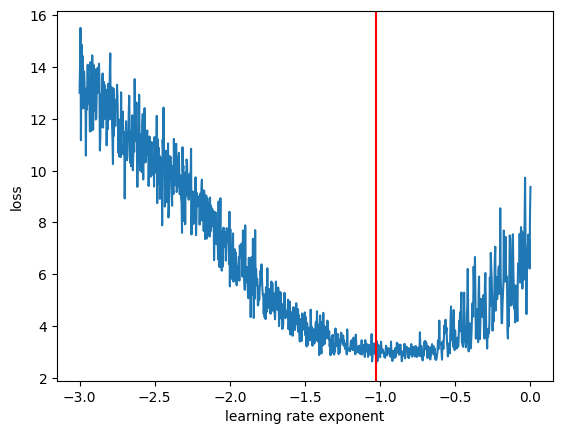

In [281]:
plt.plot(lr_i, loss_i)
plt.xlabel("learning rate exponent")
plt.ylabel("loss")
min_index = loss_i.index(min(loss_i))
plt.axvline(x=lr_i[min_index], color = 'red')
print(f"min loss occurs at lr={10**lr_i[min_index]:4f}")

#### training the model with batches and optimal training rate

In [289]:
# optimization (RL)
batch_size = 32

for i in range(10000):
    # batch the training data to optimize
    ix = torch.randint(0, X.shape[0], (batch_size,))
    
    # forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1,6) @ w1 + b1)
    logits = h @ w2 + b2 # [16, 27]
    loss = F.cross_entropy(logits, Y[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update parameters
    for p in parameters:
        p.data -= 0.094 * p.grad

print(f"epoch {i} | loss = {loss}")

epoch 9999 | loss = 1.9164142608642578


#### the achieved loss is lower than the bigram model, but this might not reflect the quality of the 3-gram model
#### the hyperparameters of the model (hidden layers, name embedding dimensionality, etc) can overfit the data
#### in production, the training data is typically split into the training split (80%), dev split (10%), and test split (10%)

In [291]:
def build_dataset(names):
    block_size = 3
    X, Y = [], []
    
    for n in names:
        context = [0] * block_size
        for ch in n + '.':
            ix = ctoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X,Y

import random
random.seed(42)
random.shuffle(names)
n1 = int(0.8*len(names))
n2 = int(0.9*len(names))

Xtr, Ytr = build_dataset(names[:n1])
Xdev, Ydev = build_dataset(names[n1:n2])
Xtst, Ytst = build_dataset(names[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [314]:
# training the network using Xtr and Ytr
batch_size = 32

for i in range(30000):
    # batch the training data to optimize
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,6) @ w1 + b1)
    logits = h @ w2 + b2 # [16, 27]
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update parameters
    for p in parameters:
        p.data -= 0.94 * p.grad

print(f"loss={loss.item()}")

loss=2.405236005783081


In [315]:
# evaluating loss with Xdev and Ydev
emb = C[Xdev]
h = torch.tanh(emb.view(-1,6) @ w1 + b1)
logits = h @ w2 + b2
loss = F.cross_entropy(logits, Ydev)
print(f"loss={loss.item()}")

loss=2.483025312423706


In [316]:
# evaluating loss with Xtr and Ytr
emb = C[Xtr]
h = torch.tanh(emb.view(-1,6) @ w1 + b1)
logits = h @ w2 + b2
loss = F.cross_entropy(logits, Ytr)
print(f"loss={loss.item()}")

loss=2.485178232192993


#### since the model performs equally well in the training and dev splits, it is **underfit**
#### this points to the model being small for the given task
#### increasing the number of neurons in the hidden layer from 100 to 300:

In [409]:
# model paramaters
C = torch.randn((27,2))
num_neurons = 300
w1 = torch.randn(6, num_neurons)
b1 = torch.randn(num_neurons)
w2 = torch.randn((num_neurons, 27))
b2 = torch.randn(27)
parameters = [C, w1, b1, w2, b2]

for p in parameters:
    p.requires_grad = True
    
print(f"number of parameters = {sum(p.nelement() for p in parameters)}")

number of parameters = 10281


In [410]:
# training the larger model
batch_size = 32
steps = 30000
lr = 0.094

step_i = []
loss_i = []

for i in range(steps):
    # batch the training data to optimize
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,6) @ w1 + b1)
    logits = h @ w2 + b2 # [16, 27]
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update parameters
    for p in parameters:
        p.data -= lr * p.grad

    step_i.append(i)
    loss_i.append(loss.item())
print(f"loss={loss.item()}")

loss=2.5585644245147705


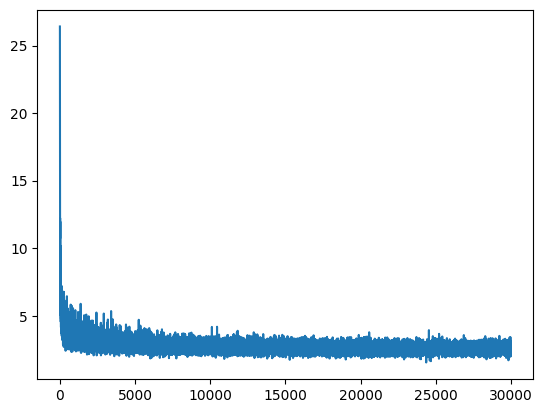

In [411]:
plt.plot(step_i, loss_i)

In [412]:
# evaluating loss with Xdev and Ydev
emb = C[Xdev]
h = torch.tanh(emb.view(-1,6) @ w1 + b1)
logits = h @ w2 + b2
loss = F.cross_entropy(logits, Ydev)
print(f"Xdev loss={loss.item()}")

# evaluating loss with Xtr and Ytr
emb = C[Xtr]
h = torch.tanh(emb.view(-1,6) @ w1 + b1)
logits = h @ w2 + b2
loss = F.cross_entropy(logits, Ytr)
print(f"Xtr loss={loss.item()}")

Xdev loss=2.5846376419067383
Xtr loss=2.5673623085021973


#### since increasing the number of neurons didn't solve the underfitting issue, the bottleneck may be the embedding dimensionality
#### NB: the model learned how to cluster the characters in a sensible way, vowels cluster together, rare characters have outlier values, etc

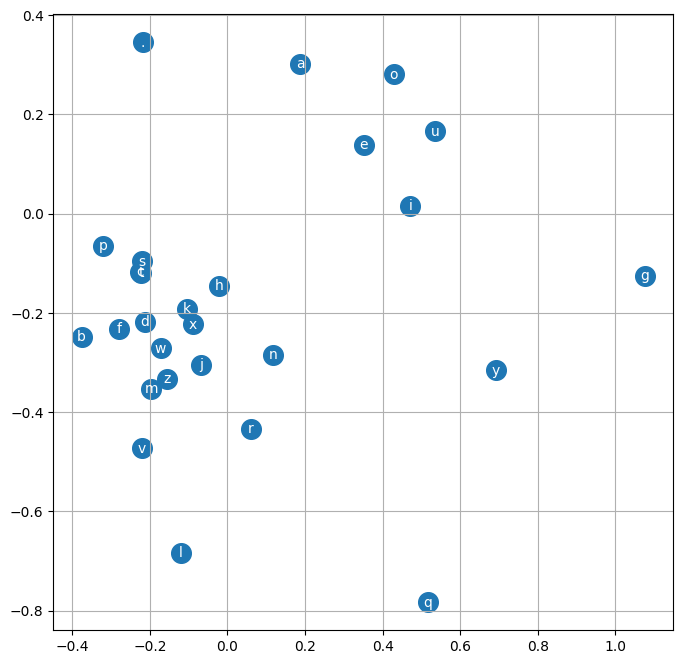

In [413]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itoc[i], ha="center", va="center", color='white')
plt.grid('minor')

In [415]:
# increasing embedding dimension to 10
# bringing neuron count down to 200
C = torch.randn((27,10))
num_neurons = 200
w1 = torch.randn(30, num_neurons)
b1 = torch.randn(num_neurons)
w2 = torch.randn((num_neurons, 27))
b2 = torch.randn(27)
parameters = [C, w1, b1, w2, b2]

for p in parameters:
    p.requires_grad = True
    
print(f"number of parameters = {sum(p.nelement() for p in parameters)}")

number of parameters = 11897


In [420]:
# training the larger model
batch_size = 32
steps = 50000
lr = 0.01
step_i = []
loss_i = []

for i in range(steps):
    # batch the training data to optimize
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,30) @ w1 + b1)
    logits = h @ w2 + b2 # [16, 27]
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update parameters
    for p in parameters:
        p.data -= lr * p.grad

    step_i.append(i)
    loss_i.append(loss.log10().item())
print(f"loss={loss.item()}")

loss=1.8646485805511475


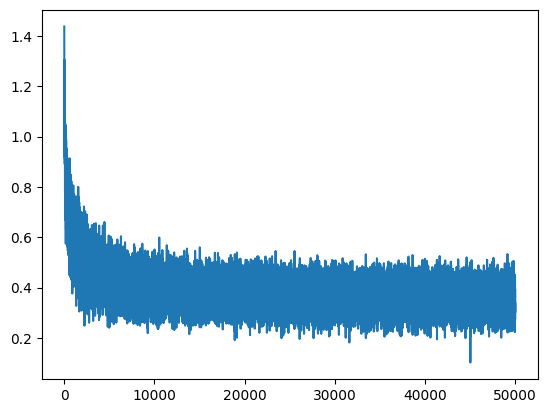

In [417]:
plt.plot(step_i, loss_i)

In [421]:
# evaluating loss with Xdev and Ydev
emb = C[Xdev]
h = torch.tanh(emb.view(-1,30) @ w1 + b1)
logits = h @ w2 + b2
loss = F.cross_entropy(logits, Ydev)
print(f"Xdev loss={loss.item()}")

# evaluating loss with Xtr and Ytr
emb = C[Xtr]
h = torch.tanh(emb.view(-1,30) @ w1 + b1)
logits = h @ w2 + b2
loss = F.cross_entropy(logits, Ytr)
print(f"Xtr loss={loss.item()}")

Xdev loss=2.1825242042541504
Xtr loss=2.1486780643463135


#### the training and dev splits are starting to diverge, indicating that the model is starting to slightly overfit
#### let's see how the 3-gram model does generating names

In [394]:
block_size = 3

for _ in range(10):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ w1 + b1)
        logits = h @ w2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix==0:
            break
    print(''.join(itoc[i] for i in out))

shawflina.
alen.
fispail.
grey.
demoney.
ney.
avis.
joshn.
lidestel.
kolo.
